## Google Drive Storage

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
main_path = "/content/drive/MyDrive/AI Models/Resume Sections Model"

## Imports

In [3]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 16.0 MB/s eta 0:00:00


In [4]:
# Install safetensors if not already installed
!pip install safetensors


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import pandas as pd
import matplotlib as mt
from datasets import load_dataset
from transformers import AutoTokenizer
import torchmetrics
from torchmetrics.classification import MulticlassAccuracy, MulticlassPrecision, MulticlassRecall, MulticlassF1Score, MulticlassConfusionMatrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from safetensors.torch import save_file

from torch.utils.data import DataLoader, Dataset

## Dataset

In [6]:
hf_dataset = load_dataset("includecctype/resume_sections", split="train")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/168 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset.json:   0%|          | 0.00/249k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/90 [00:00<?, ? examples/s]

In [7]:
hf_dataset = hf_dataset.filter(lambda x: x['class']['personal_info'] is not None)
hf_dataset = hf_dataset.filter(lambda x: x['class']['summary'] is not None)
hf_dataset = hf_dataset.filter(lambda x: x['class']['skills'] is not None)
hf_dataset = hf_dataset.filter(lambda x: x['class']['experience'] is not None)
hf_dataset = hf_dataset.filter(lambda x: x['class']['education'] is not None)
hf_dataset = hf_dataset.filter(lambda x: x['class']['certificates'] is not None)
hf_dataset = hf_dataset.filter(lambda x: x['class']['objective'] is not None)

Filter:   0%|          | 0/90 [00:00<?, ? examples/s]

Filter:   0%|          | 0/90 [00:00<?, ? examples/s]

Filter:   0%|          | 0/90 [00:00<?, ? examples/s]

Filter:   0%|          | 0/90 [00:00<?, ? examples/s]

Filter:   0%|          | 0/90 [00:00<?, ? examples/s]

Filter:   0%|          | 0/90 [00:00<?, ? examples/s]

Filter:   0%|          | 0/90 [00:00<?, ? examples/s]

## Transformer

In [8]:
tokeniser = AutoTokenizer.from_pretrained('google-bert/bert-base-cased')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

## Dataset Class

In [9]:
num_classes = 7

In [10]:
class ResumeSectionsDataset(Dataset):
    def __init__(self, dataset, tokeniser):
        self.dataset = dataset
        self.tokeniser = tokeniser

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        ## feature
        raw_feature = self.dataset[idx]['feature']
        tokenised_data = self.tokeniser(text=raw_feature, truncation=True, padding="max_length", max_length=400, return_tensors="pt")
        feature = tokenised_data['input_ids'].squeeze(0).long()

        ## label
        label = torch.full((400,), -100, dtype=torch.long)

        personal_info_arr = self.dataset[idx]['class']['personal_info']
        summary_arr = self.dataset[idx]['class']['summary']
        skills_arr = self.dataset[idx]['class']['skills']
        experience_arr = self.dataset[idx]['class']['experience']
        education_arr = self.dataset[idx]['class']['education']
        certificates_arr = self.dataset[idx]['class']['certificates']
        objective_arr = self.dataset[idx]['class']['objective']

        label[personal_info_arr[0]: personal_info_arr[1]] = 0
        label[summary_arr[0]: summary_arr[1]] = 1
        label[skills_arr[0]: skills_arr[1]] = 2
        label[experience_arr[0]: experience_arr[1]] = 3
        label[education_arr[0]: education_arr[1]] = 4
        label[certificates_arr[0]: certificates_arr[1]] = 5
        label[objective_arr[0]: objective_arr[1]] = 6

        return label, feature

In [11]:
pt_dataset = ResumeSectionsDataset(dataset=hf_dataset, tokeniser=tokeniser)

In [12]:
dataloader = DataLoader(dataset=pt_dataset, batch_size=60, shuffle=True)

## Model

In [13]:
class ResumeSectionsModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.embed = nn.Embedding(30000, 20)
        self.lstm = nn.LSTM(20, 20, batch_first=True)
        self.linear = nn.Linear(20, 7)

    def forward(self, feature):
        x = self.embed(feature)
        x, _ = self.lstm(x)
        logits = self.linear(x)

        return logits

In [14]:
model = ResumeSectionsModel()

## Training

In [15]:
optimiser = optim.AdamW(model.parameters(), lr=0.001)

In [16]:
criterion = nn.CrossEntropyLoss(ignore_index=-100)

In [17]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimiser, factor=0.9)

In [18]:
for i in range(1000):
    loss = 0
    for batch in dataloader:
        label, feature = batch

        prediction = model(feature)

        loss = criterion(prediction.view(-1, num_classes), label.view(-1))

        print(f"Loss: {loss}")

        optimiser.zero_grad()
        loss.backward()
        optimiser.step()

    scheduler.step(loss.item())

Loss: 1.9392675161361694
Loss: 1.9349085092544556
Loss: 1.9346266984939575
Loss: 1.925869107246399
Loss: 1.9269287586212158
Loss: 1.9279404878616333
Loss: 1.9227012395858765
Loss: 1.9187368154525757
Loss: 1.9170823097229004
Loss: 1.9145172834396362
Loss: 1.911516547203064
Loss: 1.9103566408157349
Loss: 1.9081357717514038
Loss: 1.8987878561019897
Loss: 1.9004546403884888
Loss: 1.9013760089874268
Loss: 1.8959757089614868
Loss: 1.8927992582321167
Loss: 1.8902074098587036
Loss: 1.8882132768630981
Loss: 1.8863734006881714
Loss: 1.8764244318008423
Loss: 1.8783541917800903
Loss: 1.8776031732559204
Loss: 1.8721891641616821
Loss: 1.8715578317642212
Loss: 1.86699640750885
Loss: 1.860998511314392
Loss: 1.8596751689910889
Loss: 1.8562119007110596
Loss: 1.8507970571517944
Loss: 1.8549410104751587
Loss: 1.8448729515075684
Loss: 1.8416038751602173
Loss: 1.8362178802490234
Loss: 1.8355367183685303
Loss: 1.8281289339065552
Loss: 1.8249084949493408
Loss: 1.819702386856079
Loss: 1.812723994255066
Loss: 1

In [19]:
save_file(model.state_dict(), f'{main_path}/model.safetensors')

## Evaluate

In [20]:
# Set model to evaluation mode
model.eval()

# Determine device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Initialize metrics
accuracy_metric = MulticlassAccuracy(num_classes=num_classes, ignore_index=-100).to(device)
precision_metric = MulticlassPrecision(num_classes=num_classes, average='none', ignore_index=-100, zero_division=0).to(device)
recall_metric = MulticlassRecall(num_classes=num_classes, average='none', ignore_index=-100, zero_division=0).to(device)
f1_metric = MulticlassF1Score(num_classes=num_classes, average='none', ignore_index=-100, zero_division=0).to(device)
confusion_matrix_metric = MulticlassConfusionMatrix(num_classes=num_classes, ignore_index=-100).to(device)

# Define class names for better readability
class_names = [
    'personal_info', 'summary', 'skills', 'experience',
    'education', 'certificates', 'objective'
]

# Create a DataLoader for evaluation (no shuffling)
eval_dataloader = DataLoader(dataset=pt_dataset, batch_size=60, shuffle=False)

print("Starting evaluation...")


Starting evaluation...


In [21]:
all_labels_flat = []
all_predictions_flat = []

with torch.no_grad():
    for batch_idx, (label, feature) in enumerate(eval_dataloader):
        feature = feature.to(device)
        label = label.to(device)

        prediction_logits = model(feature)
        predicted_classes = torch.argmax(prediction_logits, dim=-1)

        # Filter out ignored indices (-100) before updating metrics and storing for plotting
        mask = label != -100
        valid_labels = label[mask]
        valid_predictions = predicted_classes[mask]

        if valid_labels.numel() > 0:
            accuracy_metric.update(valid_predictions, valid_labels)
            precision_metric.update(valid_predictions, valid_labels)
            recall_metric.update(valid_predictions, valid_labels)
            f1_metric.update(valid_predictions, valid_labels)
            confusion_matrix_metric.update(valid_predictions, valid_labels)

            all_labels_flat.extend(valid_labels.cpu().numpy())
            all_predictions_flat.extend(valid_predictions.cpu().numpy())

# Compute final metrics
overall_accuracy = accuracy_metric.compute()
class_precision = precision_metric.compute()
class_recall = recall_metric.compute()
class_f1 = f1_metric.compute()
conf_matrix = confusion_matrix_metric.compute()

print("\n--- Evaluation Results ---")
print(f"Overall Accuracy: {overall_accuracy.item():.4f}")

print("\nClass-wise Metrics:")
for i, class_name in enumerate(class_names):
    print(f"  {class_name}:")
    print(f"    Precision: {class_precision[i].item():.4f}")
    print(f"    Recall:    {class_recall[i].item():.4f}")
    print(f"    F1-Score:  {class_f1[i].item():.4f}")



--- Evaluation Results ---
Overall Accuracy: 0.9996

Class-wise Metrics:
  personal_info:
    Precision: 1.0000
    Recall:    1.0000
    F1-Score:  1.0000
  summary:
    Precision: 0.9989
    Recall:    1.0000
    F1-Score:  0.9995
  skills:
    Precision: 1.0000
    Recall:    1.0000
    F1-Score:  1.0000
  experience:
    Precision: 0.9998
    Recall:    1.0000
    F1-Score:  0.9999
  education:
    Precision: 1.0000
    Recall:    0.9985
    F1-Score:  0.9993
  certificates:
    Precision: 0.9995
    Recall:    1.0000
    F1-Score:  0.9997
  objective:
    Precision: 1.0000
    Recall:    0.9988
    F1-Score:  0.9994


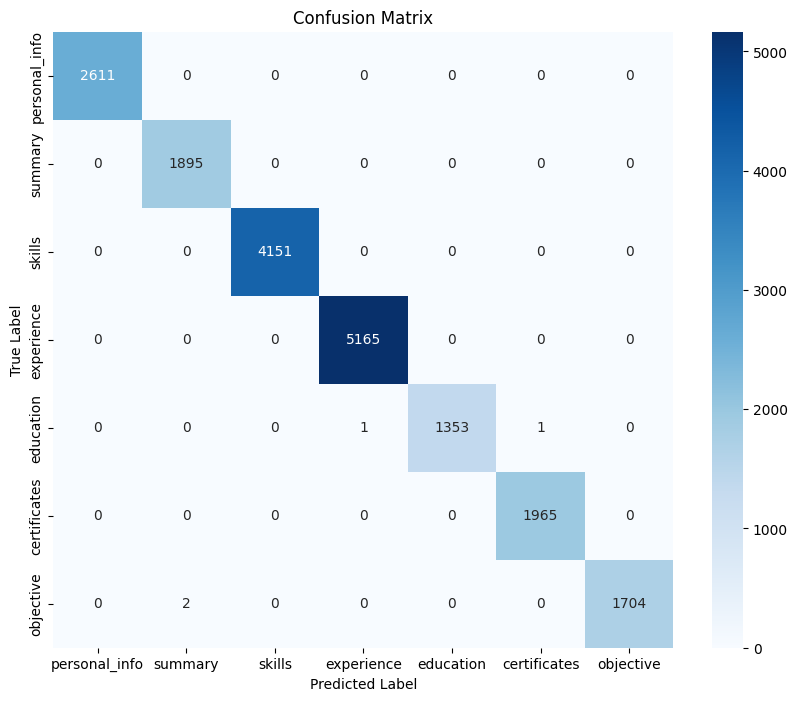

In [22]:
# Plotting Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix.cpu().numpy(), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


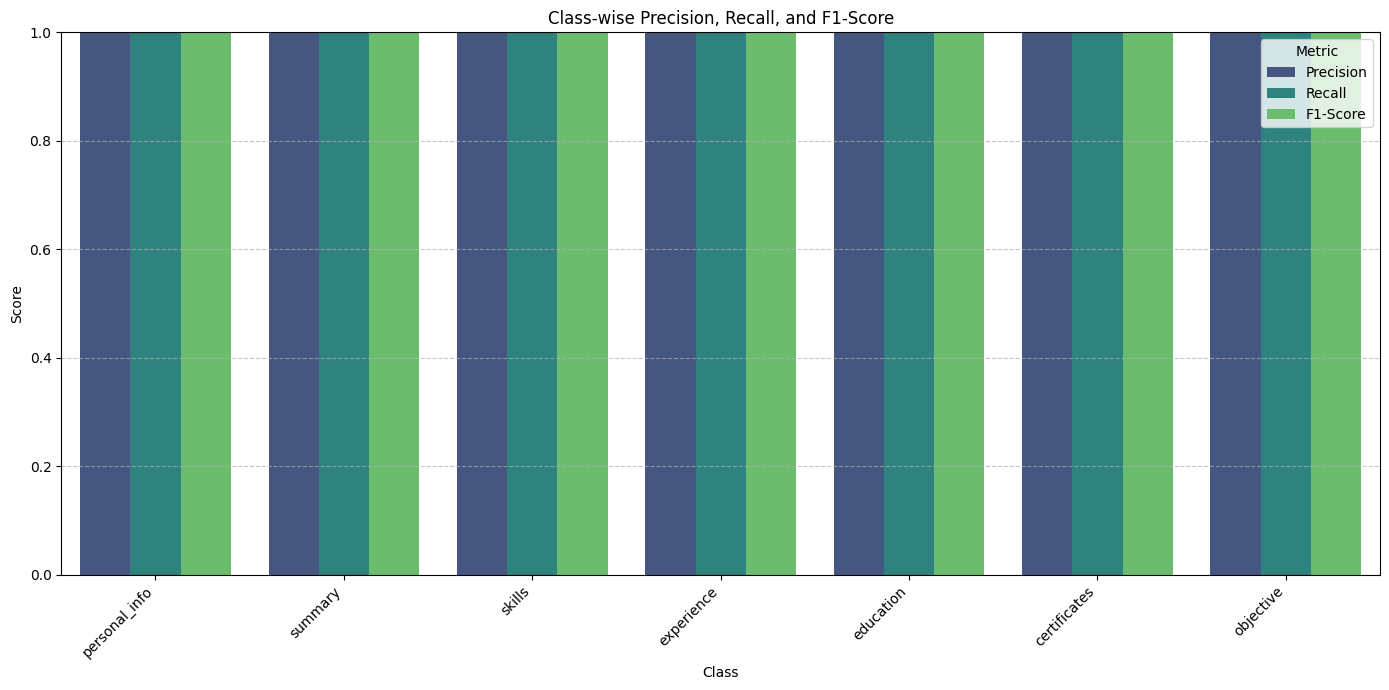

In [23]:
# Plotting class-wise Precision, Recall, F1-Score
import pandas as pd

metrics_df = pd.DataFrame({
    'Class': class_names,
    'Precision': [p.item() for p in class_precision],
    'Recall': [r.item() for r in class_recall],
    'F1-Score': [f.item() for f in class_f1]
})

metrics_df_melted = metrics_df.melt(id_vars='Class', var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 7))
sns.barplot(x='Class', y='Score', hue='Metric', data=metrics_df_melted, palette='viridis')
plt.title('Class-wise Precision, Recall, and F1-Score')
plt.xlabel('Class')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1) # Metrics are typically between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
